In [1]:
# ===============================================
# Code Block 1 — Imports, Paths, Load Case Dataset
# ===============================================

import os
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import entropy
import warnings
warnings.filterwarnings("ignore")

IN_DIR = "../data/processed"
OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

CASE_FILE = os.path.join(IN_DIR, "case_features_with_outliers.csv")
OUT_FILE = os.path.join(OUT_DIR, "case_scores.csv")

if not os.path.exists(CASE_FILE):
    raise FileNotFoundError(f"Missing case_features_with_outliers.csv at {CASE_FILE}")

case_df = pd.read_csv(CASE_FILE)

print("Loaded case dataset:", case_df.shape)
display(case_df.head())


Loaded case dataset: (3183, 21)


,case_id,case_start,case_end,cycle_time_seconds,n_events,n_unique_activities,n_unique_resources,variant,variant_length,rework_count,...,wait_time_seconds,processing_time_seconds,municipality,case_status,case_procedure,cycle_time_hours,wait_time_hours,processing_time_hours,case_outlier,iso_outlier
0,10002463,2014-08-05 00:00:00+00:00,2014-10-07 11:55:52+00:00,5486152.0,46,44,1,register submission date request->regular proc...,46,2,...,5486152.0,0.0,BPIC15_4,O,Unknown,1523.931111,1523.931111,0.0,False,False
1,10003257,2014-08-05 00:00:00+00:00,2014-08-06 09:35:43+00:00,120943.0,13,13,1,register submission date request->OLO messagin...,13,0,...,120943.0,0.0,BPIC15_4,G,Unknown,33.595278,33.595278,0.0,False,False
2,10009280,2014-04-11 00:00:00+00:00,2014-06-05 00:00:00+00:00,4752000.0,45,42,1,register submission date request->OLO messagin...,45,3,...,4752000.0,0.0,BPIC15_1,O,Unknown,1320.000000,1320.000000,0.0,False,False
3,10044881,2014-08-14 00:00:00+00:00,2014-08-14 12:00:38+00:00,43238.0,13,13,1,OLO messaging active->send confirmation receip...,13,0,...,43238.0,0.0,BPIC15_4,G,Unknown,12.010556,12.010556,0.0,False,False
4,10051546,2014-04-17 00:00:00+00:00,2014-06-26 00:00:00+00:00,6048000.0,57,53,1,create procedure confirmation->create subcases...,57,4,...,6048000.0,0.0,BPIC15_1,O,Unknown,1680.000000,1680.000000,0.0,True,False


In [2]:
# ===============================================
# Code Block 2 — Select Case Metrics & Clean Data
# ===============================================

case_metrics = [
    "cycle_time_hours",
    "wait_time_hours",
    "processing_time_hours",
    "rework_count",
    "total_cost",
    "variant_length"
]

# Keep only numeric metrics
case_numeric = case_df[case_metrics].copy()

# Replace infs & NaNs
case_numeric = case_numeric.replace([np.inf, -np.inf], np.nan)
case_numeric = case_numeric.fillna(case_numeric.median())

print("Metrics (cleaned):")
display(case_numeric.head())


Metrics (cleaned):


,cycle_time_hours,wait_time_hours,processing_time_hours,rework_count,total_cost,variant_length
0,1523.931111,1523.931111,0.0,2,18350.52562,46
1,33.595278,33.595278,0.0,0,0.00000,13
2,1320.000000,1320.000000,0.0,3,7069.18725,45
3,12.010556,12.010556,0.0,0,0.00000,13
4,1680.000000,1680.000000,0.0,4,94153.53480,57


In [3]:
# ===============================================
# Code Block 3 — Transform Highly Skewed Metrics
# ===============================================

case_numeric["total_cost"] = np.log1p(case_numeric["total_cost"])
case_numeric["variant_length"] = np.log1p(case_numeric["variant_length"])

print("Applied log-transform to skewed metrics (cost, variant_length).")
display(case_numeric.head())


Applied log-transform to skewed metrics (cost, variant_length).


,cycle_time_hours,wait_time_hours,processing_time_hours,rework_count,total_cost,variant_length
0,1523.931111,1523.931111,0.0,2,9.817468,3.850148
1,33.595278,33.595278,0.0,0,0.000000,2.639057
2,1320.000000,1320.000000,0.0,3,8.863642,3.828641
3,12.010556,12.010556,0.0,0,0.000000,2.639057
4,1680.000000,1680.000000,0.0,4,11.452693,4.060443


In [4]:
# ===============================================
# Code Block 4 — Normalize Metrics (0–1)
# ===============================================

def normalize_series_invert(s):
    """Normalize so LOWER = BETTER becomes HIGHER = BETTER."""
    s_norm = (s - s.min()) / (s.max() - s.min() + 1e-12)
    return 1 - s_norm

def normalize_series(s):
    """Normalize so HIGHER = BETTER."""
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

case_norm = pd.DataFrame(index=case_df.index)

# Invert metrics where lower = better
case_norm["cycle"] = normalize_series_invert(case_numeric["cycle_time_hours"])
case_norm["wait"]  = normalize_series_invert(case_numeric["wait_time_hours"])
case_norm["rework"] = normalize_series_invert(case_numeric["rework_count"])
case_norm["cost"] = normalize_series_invert(case_numeric["total_cost"])

# Processing time can be ambiguous; treat as direct:
case_norm["processing"] = normalize_series(case_numeric["processing_time_hours"])

# Variant_length is ambiguous; treat as neutral or invert (we invert)
case_norm["variant"] = normalize_series_invert(case_numeric["variant_length"])

print("Normalized metrics (0–1):")
display(case_norm.head())


Normalized metrics (0–1):


,cycle,wait,rework,cost,processing,variant
0,0.969502,0.969502,0.999982,0.476378,0.0,0.711694
1,0.999328,0.999328,1.000000,1.000000,0.0,0.822294
2,0.973583,0.973583,0.999974,0.527251,0.0,0.713658
3,0.999760,0.999760,1.000000,1.000000,0.0,0.822294
4,0.966378,0.966378,0.999965,0.389162,0.0,0.692489


In [6]:
# ===============================================
# Code Block 5 — Clean Data + PCA Weighting
# ===============================================

# --- FIX STEP 1: Replace infinities and NaNs (caused by normalization)
case_norm = case_norm.replace([np.inf, -np.inf], np.nan)
case_norm = case_norm.fillna(case_norm.median())

# --- FIX STEP 2: Detect and drop constant columns (std = 0)
constant_cols = [c for c in case_norm.columns if case_norm[c].std() == 0]

if len(constant_cols) > 0:
    print("Dropping constant columns (cannot be used in PCA):", constant_cols)
    case_norm = case_norm.drop(columns=constant_cols)

# --- FIX STEP 3: Final NaN check after dropping constants
if case_norm.isna().sum().sum() > 0:
    print("WARNING: Remaining NaNs detected; filling with 0.")
    case_norm = case_norm.fillna(0)

print("\nCase_norm is clean for PCA. Final shape:", case_norm.shape)
display(case_norm.head())

# --- PCA COMPUTATION ---
scaler = StandardScaler()
X = scaler.fit_transform(case_norm)

pca = PCA(n_components=1)
pca.fit(X)

loadings = np.abs(pca.components_[0])
w_pca = loadings / loadings.sum()

print("\nPCA Weights:")
for col, w in zip(case_norm.columns, w_pca):
    print(f"{col}: {w:.3f}")


Dropping constant columns (cannot be used in PCA): ['processing']

Case_norm is clean for PCA. Final shape: (3183, 5)


,cycle,wait,rework,cost,variant
0,0.969502,0.969502,0.999982,0.476378,0.711694
1,0.999328,0.999328,1.000000,1.000000,0.822294
2,0.973583,0.973583,0.999974,0.527251,0.713658
3,0.999760,0.999760,1.000000,1.000000,0.822294
4,0.966378,0.966378,0.999965,0.389162,0.692489



PCA Weights:
cycle: 0.270
wait: 0.270
rework: 0.140
cost: 0.110
variant: 0.209


In [7]:
# ===============================================
# Code Block 6 — Entropy Weighting
# ===============================================

mm = MinMaxScaler()
vals = mm.fit_transform(case_norm)

P = vals / (vals.sum(axis=0) + 1e-12)
E = np.array([entropy(P[:,i]) for i in range(P.shape[1])])
d = 1 - E / np.log(len(P))

w_entropy = d / d.sum()

print("Entropy Weights:")
for col, w in zip(case_norm.columns, w_entropy):
    print(f"{col}: {w:.3f}")


Entropy Weights:
cycle: 0.023
wait: 0.023
rework: 0.003
cost: 0.926
variant: 0.025


In [8]:
# ===============================================
# Code Block 7 — Final Case Weights (Average)
# ===============================================

w_final = (w_pca + w_entropy) / 2
w_final = w_final / w_final.sum()

case_weights = dict(zip(case_norm.columns, w_final))

print("Final Case Weights:")
for k,v in case_weights.items():
    print(f"{k}: {v:.3f}")


Final Case Weights:
cycle: 0.147
wait: 0.147
rework: 0.072
cost: 0.518
variant: 0.117


In [9]:
# ===============================================
# Code Block 8 — Compute Case Score
# ===============================================

# Weighted sum
case_raw_score = np.zeros(len(case_norm))
for col in case_norm.columns:
    case_raw_score += case_norm[col] * case_weights[col]

# Normalize to 0–1
case_score = (case_raw_score - case_raw_score.min()) / (case_raw_score.max() - case_raw_score.min())

# Convert to pandas
case_df["case_score"] = case_score.round(3)

print("Case Score Sample:")
display(case_df[["case_id", "case_score"]].head(10))


Case Score Sample:


,case_id,case_score
0,10002463,0.686
1,10003257,0.979
2,10009280,0.714
3,10044881,0.979
4,10051546,0.638
5,10053184,0.672
6,10061287,0.705
7,10063994,0.638
8,10065028,0.980
9,10069618,0.929


In [10]:
# ===============================================
# Code Block 9 — Save case_scores.csv
# ===============================================

out_cols = ["case_id", "case_score", "case_outlier", "iso_outlier"]
out_cols = [c for c in out_cols if c in case_df.columns]

case_out = case_df[out_cols].round(3)

case_out.to_csv(OUT_FILE, index=False)

print(f"Saved case_scores.csv to:\n{OUT_FILE}")


Saved case_scores.csv to:
../data/processed\case_scores.csv


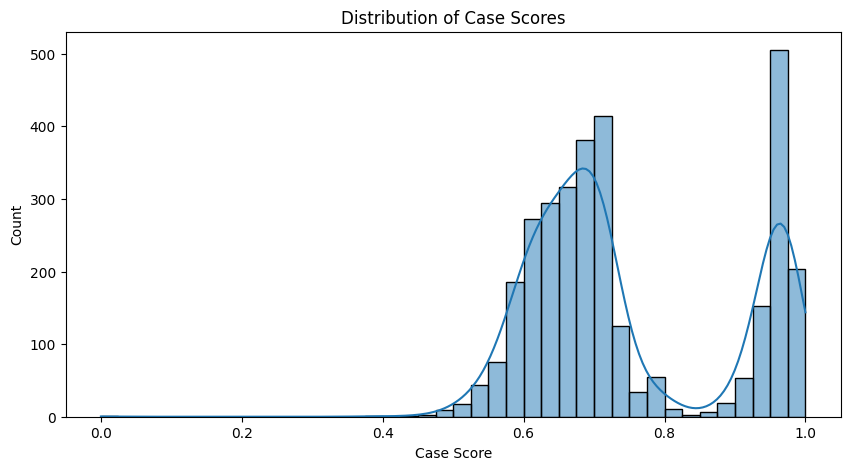

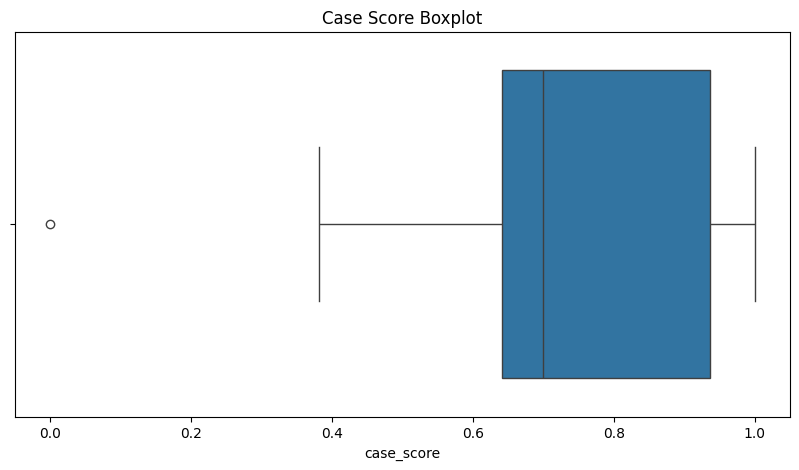

Top 10 Cases:


,case_id,case_start,case_end,cycle_time_seconds,n_events,n_unique_activities,n_unique_resources,variant,variant_length,rework_count,...,processing_time_seconds,municipality,case_status,case_procedure,cycle_time_hours,wait_time_hours,processing_time_hours,case_outlier,iso_outlier,case_score
1196,4119890,2011-07-15 00:00:00+00:00,2011-07-15 00:00:00+00:00,0.0,1,1,1,register submission date request,1,0,...,0.0,BPIC15_2,G,Unknown,0.000000,0.000000,0.0,True,False,1.000
236,11467444,2015-03-02 00:00:00+00:00,2015-03-02 00:00:00+00:00,0.0,1,1,1,cancel case,1,0,...,0.0,BPIC15_4,G,Unknown,0.000000,0.000000,0.0,True,False,1.000
580,21575612,2014-05-26 00:00:00+00:00,2014-05-26 00:00:00+00:00,0.0,1,1,1,received OLO documents,1,0,...,0.0,BPIC15_2,G,Unknown,0.000000,0.000000,0.0,True,False,1.000
702,2760933,2010-10-05 00:00:00+00:00,2010-10-07 14:57:14+00:00,226634.0,2,2,1,register submission date request->phase applic...,2,0,...,0.0,BPIC15_1,G,Unknown,62.953889,62.953889,0.0,True,False,0.995
2354,6761985,2012-12-21 00:00:00+00:00,2012-12-28 12:04:32+00:00,648272.0,2,2,1,register submission date request->cancel case,2,0,...,0.0,BPIC15_4,G,Unknown,180.075556,180.075556,0.0,True,False,0.995
704,2799084,2010-10-13 00:00:00+00:00,2010-10-19 12:47:20+00:00,564440.0,2,2,1,register submission date request->phase applic...,2,0,...,0.0,BPIC15_1,G,Unknown,156.788889,156.788889,0.0,True,False,0.995
810,3184863,2010-12-06 00:00:00+00:00,2010-12-06 12:52:33+00:00,46353.0,3,3,1,register submission date request->phase applic...,3,0,...,0.0,BPIC15_3,G,Unknown,12.875833,12.875833,0.0,True,False,0.993
763,3088479,2010-10-29 00:00:00+00:00,2010-11-05 10:21:55+00:00,642115.0,3,3,1,register submission date request->phase applic...,3,0,...,0.0,BPIC15_3,G,Unknown,178.365278,178.365278,0.0,True,False,0.992
761,3087475,2010-10-29 00:00:00+00:00,2010-11-05 10:11:08+00:00,641468.0,3,3,1,register submission date request->phase applic...,3,0,...,0.0,BPIC15_3,G,Unknown,178.185556,178.185556,0.0,True,False,0.992
1463,4685417,2011-02-13 00:00:00+00:00,2011-02-14 11:51:11+00:00,129071.0,3,3,1,register submission date request->phase applic...,3,0,...,0.0,BPIC15_4,G,Unknown,35.853056,35.853056,0.0,True,False,0.992


Bottom 10 Cases:


,case_id,case_start,case_end,cycle_time_seconds,n_events,n_unique_activities,n_unique_resources,variant,variant_length,rework_count,...,processing_time_seconds,municipality,case_status,case_procedure,cycle_time_hours,wait_time_hours,processing_time_hours,case_outlier,iso_outlier,case_score
3182,Unknown,2009-11-18 00:00:00+00:00,2015-08-01 00:00:00+00:00,179884800.0,113927,321,57,enter senddate procedure confirmation->registe...,113927,113606,...,0.0,BPIC15_4,G,Unknown,49968.000000,49968.000000,0.0,True,True,0.000
1942,5726449,2010-05-13 00:00:00+00:00,2013-10-24 11:08:54+00:00,108904134.0,85,71,1,enter senddate acknowledgement->register submi...,85,14,...,0.0,BPIC15_3,G,Uitgebreid,30251.148333,30251.148333,0.0,True,True,0.381
1399,4565231,2012-01-31 00:00:00+00:00,2014-08-07 00:00:00+00:00,79401600.0,98,81,1,register submission date request->OLO messagin...,98,17,...,0.0,BPIC15_1,O,Uitgebreid,22056.000000,22056.000000,0.0,True,True,0.430
1349,4459915,2010-12-24 00:00:00+00:00,2013-04-03 09:06:38+00:00,71831198.0,65,55,1,register submission date request->phase applic...,65,10,...,0.0,BPIC15_4,O,Uitgebreid,19953.110556,19953.110556,0.0,True,True,0.452
3045,9236448,2013-09-20 00:00:00+00:00,2015-01-12 10:03:41+00:00,41421821.0,102,93,1,register submission date request->OLO messagin...,102,9,...,0.0,BPIC15_5,G,Uitgebreid,11506.061389,11506.061389,0.0,True,True,0.461
206,11293939,2014-05-23 00:00:00+00:00,2015-01-20 14:31:47+00:00,20961107.0,80,72,1,register submission date request->forward to t...,80,8,...,0.0,BPIC15_5,G,Unknown,5822.529722,5822.529722,0.0,True,True,0.480
1924,5672213,2013-03-06 00:00:00+00:00,2015-01-28 00:00:00+00:00,59875200.0,71,58,1,register submission date request->OLO messagin...,71,13,...,0.0,BPIC15_3,O,Uitgebreid,16632.000000,16632.000000,0.0,True,True,0.480
1951,5732411,2013-03-22 00:00:00+00:00,2015-03-05 00:00:00+00:00,61603200.0,73,67,1,register submission date request->OLO messagin...,73,6,...,0.0,BPIC15_3,G,Uitgebreid,17112.000000,17112.000000,0.0,True,True,0.491
2350,6759705,2014-01-28 00:00:00+00:00,2014-12-12 00:00:00+00:00,27475200.0,75,70,1,register submission date request->OLO messagin...,75,5,...,0.0,BPIC15_3,G,Uitgebreid,7632.000000,7632.000000,0.0,True,True,0.495
1968,5783355,2012-01-12 00:00:00+00:00,2014-03-04 12:58:24+00:00,67611504.0,68,64,1,register submission date request->phase applic...,68,4,...,0.0,BPIC15_4,O,Uitgebreid,18780.973333,18780.973333,0.0,True,True,0.496


In [11]:
# ===============================================
# Code Block 10 — Diagnostics & Plots
# ===============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(case_df["case_score"], kde=True, bins=40)
plt.title("Distribution of Case Scores")
plt.xlabel("Case Score")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=case_df["case_score"])
plt.title("Case Score Boxplot")
plt.show()

print("Top 10 Cases:")
display(case_df.sort_values("case_score", ascending=False).head(10))

print("Bottom 10 Cases:")
display(case_df.sort_values("case_score").head(10))
